# Assignment 5: Neuroevolution

**Goal**: Implement an Evolutionary Algorithm to optimize an Artificial Neural Network (ANN) based controller for the CartPole task in OpenAI Gym environment.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

CartPole evaluation environment functions are provided. Your goal is to implement your ANN to control the cartpole and use your Evolutionary Algorithm to optimize the ANN parameters (weights).

Please answer the `Questions` and implement coding `Tasks` by filling **PLEASE FILL IN** sections. *Documentation* of your code is also important. You can find the grading scheme in implementation cells.

**Install Prerequisites**

In [25]:
# Run this cell to install the required libraries
%pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


**Imports**

In [26]:
# Necessary libraries
import matplotlib.pyplot as plt
import numpy as np


In [27]:
# Enables inline matplotib graphs
%matplotlib inline
# Comment the line above and uncomment the lines below to have interactive plots
# WARN: may cause dependency issues
# %matplotlib qt5
# %pip install PyQt5
# plt.ion()

In [28]:
%pip install gymnasium
import gymnasium as gym

Note: you may need to restart the kernel to use updated packages.


---
**Question 1 (0-0.25-0.5 pt):** Following link provides more information about the CartPole environemnt we would like to find an ANN to control: https://www.gymlibrary.dev/environments/classic_control/cart_pole/

Please have a look at the link and note the observation and action spaces, how many dimensions they have? Are they continous or discrete, and what kinds of value they can get?

**Answer:**


Action Space is Discrete(2), it takes {0, 1}
Shape - (1,)

#### Observation Space
The observation space has 4 dimensions and is continuous.
The four observations are:
- Cart Position
  - Continuous value
  - Range: approximately −4.8 to 4.8
- Cart Velocity
  - Continuous value
  - Range: unbounded (−inf to inf)
- Pole Angle
  - Continuous value
  - Range: approximately −0.418 to 0.418 radians (about ±24°)
- Pole Angular Velocity
  - Continuous value
  - Range: unbounded (−inf to inf)

#### Action Space
The action space is discrete with 2 possible actions: \
0 - Push cart to the left \
1 - Push cart to the right \
So the action space is a discrete space with 2 values: {0,1}.

---
**Question 2 (0-0.25-0.5 pt):** What is your proposed ANN architecture and why? Please also discuss the activation functions you choose.

**Answer:**

My ANN architecture for the CartPole problem is a feedforward neural network, specifically a multilayer perceptron (MLP). The network has an input layer with 4 neurons, one for each observation value provided by the environment: cart position, cart velocity, pole angle, and pole angular velocity.

The network contains one hidden layer with 8 neurons. This layer allows the network to learn nonlinear relationships between the input state variables and the appropriate control action. Since the CartPole state space is small, a simple architecture with a single hidden layer is sufficient to approximate a good control policy while keeping the model efficient and easy to optimize.

The output layer contains 2 neurons, corresponding to the two possible actions: push the cart left or push the cart right.

\
**Architecture:** \
4 to 8 to 2 \
 \
This architecture works well because the CartPole problem has only a few input variables and requires relatively simple control logic. A deeper or more complex network would not provide significant advantages and would increase the search space for the evolutionary algorithm.

I also did not use recurrent connections because the environment already provides velocity and angular velocity in the observation space. These values describe how the system is changing over time, meaning the agent receives sufficient information about the system dynamics without needing memory of past states.

\
**Activation functions** \
For the hidden layer, I used the tanh activation function. Tanh introduces nonlinearity into the network and keeps the neuron outputs within the range [−1,1], which helps stabilize the learning process and allows the network to represent nonlinear relationships between the input variables.

The output layer uses a linear activation function. The two output neurons produce scores for the two possible actions, and the action with the larger value is selected using an argmax operation.

---
**Task 1: Implementation of Evolutionary Algrotihm (0-1.6-3.8-4.2-5 pt):** Implement your evolutionary algorithm to find an ANN controller for the CartPole task.

In [80]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 1.6 pts if the code works but some functions are incorrect and it is badly explained
# 3.8 pts if the code works but some functions are incorrect but it is explained well
# 4.2 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 5 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


# Artificial Neural Network parameters (weights)
# See here: https://www.gymlibrary.dev/environments/classic_control/cart_pole/ for input and output space
# PLEASE SPECIFY BELOW
# ============================================================
# CartPole observation space = 4 continuous values -- [cart position, cart velocity, pole angle, pole angular velocity]
# CartPole action space = 2 discrete actions -- 0 = push left, 1 = push right
#
# ANN:
#   input layer  = 4 neurons
#   hidden layer = 8 neurons
#   output layer = 2 neurons
# ============================================================
inp = 4   # Number of input neurons
hid = 8   # Number of hidden neurons
out = 2   # Number of output neurons
###################
# inp*hid + hid + hid*out + out
n_params = inp * hid + hid + hid * out + out




# ============================================================
# Helper function:
# Convert a flat parameter vector x into ANN weight matrices/biases
# ============================================================
def decode_network(x):
    """
    Convert a 1D parameter vector into ANN weights and biases.

    :param x : np.ndarray of shape (n_params,)
            Flat vector containing all ANN parameters.

    :returns W1, b1, W2, b2 : tuple
            Weight matrices and bias vectors for a 1-hidden-layer ANN.
    """
    idx = 0

    # First layer weights: shape (inp, hid)
    W1 = x[idx: idx + inp * hid].reshape(inp, hid)
    idx += inp * hid

    # First layer bias: shape (hid,)
    b1 = x[idx: idx + hid]
    idx += hid

    # Second layer weights: shape (hid, out)
    W2 = x[idx: idx + hid * out].reshape(hid, out)
    idx += hid * out

    # Second layer bias: shape (out,)
    b2 = x[idx: idx + out]

    return W1, b1, W2, b2


# ============================================================
# Helper Function
# Forward pass through the ANN
# ============================================================
def ann_forward(x, observation):
    """
    Compute the ANN output for one CartPole observation.
    Network: observation -> hidden(tanh) -> output(linear)

    :param x : np.ndarray
        Flat vector of ANN parameters.
    :param observation : np.ndarray of shape (4,)
        Current CartPole state.

   :returns output : np.ndarray of shape (2,)
        One score per action.
    """
    W1, b1, W2, b2 = decode_network(x)

    # Hidden layer pre-activation
    z1 = observation @ W1 + b1

    # Hidden layer activation
    h1 = np.tanh(z1)

    # Output layer (linear)
    output = h1 @ W2 + b2

    return output


# ============================================================
# Helper Function
# Choose discrete action from ANN output
# ============================================================
def select_action(x, observation):
    """
    Select an action using the ANN.
    Compute two output scores and choose the action with
    the highest score using argmax.

    :returns int : 0 or 1
    """
    output = ann_forward(x, observation)
    action = int(np.argmax(output))
    return action


#Open AI gym environment
env = gym.make("CartPole-v1")

# CartPole evaluation function
def cartpole(x):

    ###########
    # PLEASE FILL IN
    # Hint: x is an individual in evolutionary algorithms and needs to map to the connection weights of ANNs

    #########

    # Reset environment
    observation, info = env.reset(seed = 0)

    rew = 0 # Initial reward
    step = 0 #step counter
    done = False
    maxStep = 1000  # maximum number of steps
    while not done and step<maxStep:

        # Feed current observation into ANN and choose an action
        action = select_action(x, observation)

        # action should be provided based on the output of the artifial neural network
        observation, reward, done, tr, info = env.step(action)
        step+=1 # step counter
        rew = rew + reward # after each step increment reward

        done = done or tr


    env.close()
    return np.minimum(maxStep, rew) # return the reward or maxStep (if maxStep < 1000, this means that pole fell)



# CartPole evaluation function with video recording
def cartpole_record_video(x):
    tmp_env = gym.make("CartPole-v1", render_mode="rgb_array")

    # Video recording function - be sure to check the folder path - you should see the video here:content/video/cartpole
    env = gym.wrappers.RecordVideo(env=tmp_env, video_folder="content/video/cartpole", name_prefix="cartpole")

    ###########
    # PLEASE FILL IN
    # Hint: x is an individual in evolutionary algorithms and needs to map to the connection weights of ANNs

    #########

    # Reset environment
    observation, info = env.reset(seed = 0)


    rew = 0 # Initial reward
    step = 0 #step counter
    done = False
    maxStep = 1000  # maximum number of steps
    while not done and step<1000: # run nStep number of time

      ###################
      # PLEASE FILL IN
      # Hint: Provide input to ANN and find the output to be the action
      action = select_action(x, observation)

      # action should be provided based on the output of the artifial neural network
      observation, reward, done, tr, info = env.step(action)
      done = done or tr

      step+=1 # step counter
      rew = rew + reward # after each step increment reward
      env.render()

    env.close()
    return np.minimum(maxStep, rew) # return the reward or maxStep (if maxStep < 1000, this means that pole fell)




# CartPole evaluation function for visualizing the cartpole environment
def cartpole_visualize(x):
    tmp_env = gym.make("CartPole-v1", render_mode="human")

    ###########
    # PLEASE FILL IN
    # Hint: x is an individual in evolutionary algorithms and needs to map to the connection weights of ANNs

    #########

    # Reset environment
    observation, info = tmp_env.reset(seed = 0)

    rew = 0 # Initial reward
    step = 0; #step counter
    done = False
    maxStep = 1000  # maximum number of steps
    while not done and step<1000: # run nStep number of time

      ###################
      # PLEASE FILL IN
      # Hint: Provide input to ANN and find the output to be the action
      action = select_action(x, observation)

      # action should be provided based on the output of the artifial neural network
      observation, reward, done, tr, info = tmp_env.step(action)
      done = done or tr

      step+=1 # step counter
      rew = rew + reward # after each step increment reward
      tmp_env.render()

    tmp_env.close()
    return np.minimum(maxStep, rew) # return the reward or maxStep (if maxStep < 1000, this means that pole fell)




# Implement your Evolutionary Algorithm to find the ANN weigths that can balance the CartPole
# Feel free to add any functions, such as initialization, crossover, etc.. to make it work!


# ============================================================
# Evolutionary Algorithm helper functions
# ============================================================
def initialize_population(population_size, dimension, low=-1.0, high=1.0):
    """
    Initialize a population of real-valued vectors.

    Each individual represents all ANN weights and biases.
    """
    return np.random.uniform(low, high, size=(population_size, dimension))


def tournament_selection(population, fitness, tournament_size=3):
    """
    Select one parent using tournament selection.

    Since we are minimizing fitness, smaller is better.
    """
    indices = np.random.choice(len(population), size=tournament_size, replace=False)
    best_idx = indices[np.argmax(fitness[indices])]
    return population[best_idx].copy()


def blend_crossover(parent1, parent2):
    """
    Arithmetic / blend crossover for real-valued genes.

    child1 = alpha*p1 + (1-alpha)*p2
    child2 = alpha*p2 + (1-alpha)*p1
    """
    alpha = np.random.rand()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1
    return child1, child2


def gaussian_mutation(individual, m_rate=0.1, sigma=0.1):
    """
    Mutate an individual by adding Gaussian noise to each gene
    with probability m_rate.
    """
    mutant = individual.copy()
    mutation_mask = np.random.rand(len(mutant)) < m_rate
    noise = np.random.normal(0, sigma, size=len(mutant))
    mutant[mutation_mask] += noise[mutation_mask]
    return mutant


# ============================================================
# Evolutionary Algorithm
# ============================================================
def ea(
    population_size,
    max_fit_evals,      # Maximum number of fitness evaluations
    p_crossover,        # Probability of crossover
    m_rate,             # Mutation rate
    objective_function, # Function to minimize
):
    """
    Evolutionary Algorithm to optimize ANN weights for CartPole.

    :param population_size : int
        Number of individuals in the population.
    :param max_fit_evals : int
        Maximum number of objective function evaluations.
    :param p_crossover : float
        Probability of applying crossover.
    :param m_rate : float
        Per-gene mutation probability.
    :param objective_function : callable
        Function to minimize.


    :return x_best : np.ndarray
        Best ANN parameter vector found.
    :return f_best_history : list
        Best fitness value after each generation.
        Remember: lower fitness is better because we minimize.
        If using objective_cartpole, fitness = -reward.
    """

    ###################
    # PLEASE FILL IN
    # Hint: your implementation of your evolutionary algorithm
    # You may use the code you previously implemented during the course


    # ----- Step 1: initialize population -----
    population = initialize_population(population_size, n_params, low=-1.0, high=1.0)

    # Evaluate initial population
    fitness = np.array([objective_function(ind) for ind in population])
    fit_evals = population_size

    # Track best solution seen so far
    best_idx = np.argmax(fitness)
    x_best = population[best_idx].copy()
    f_best = fitness[best_idx]

    # Store best fitness per generation for plotting/analysis
    x_best_history = [x_best.copy()]
    f_best_history = [f_best]

    generation = 0

    # ----- Step 2: evolutionary loop -----
    while fit_evals < max_fit_evals:
        generation += 1

        new_population = []

        # Elitism:
        # carry the current best solution directly into next generation
        elite_idx = np.argmax(fitness)
        elite = population[elite_idx].copy()
        new_population.append(elite)

        # Fill the rest of the new population
        while len(new_population) < population_size:

            # Parent selection
            parent1 = tournament_selection(population, fitness, tournament_size=3)
            parent2 = tournament_selection(population, fitness, tournament_size=3)

            # Crossover
            if np.random.rand() < p_crossover:
                child1, child2 = blend_crossover(parent1, parent2)
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            # Mutation
            child1 = gaussian_mutation(child1, m_rate=m_rate, sigma=0.1)
            child2 = gaussian_mutation(child2, m_rate=m_rate, sigma=0.1)

            # Add children to next generation
            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        # Convert list to numpy array
        population = np.array(new_population)

        # Evaluate new population
        fitness = np.array([objective_function(ind) for ind in population])
        fit_evals += population_size

        # Update global best
        gen_best_idx = np.argmax(fitness)
        gen_best_x = population[gen_best_idx].copy()
        gen_best_fit = fitness[gen_best_idx]

        if gen_best_fit > f_best:
            f_best = gen_best_fit
            x_best = gen_best_x.copy()

        x_best_history.append(x_best.copy())
        f_best_history.append(f_best)


        # Optional progress print
        print(
            f"Generation {generation:3d} | "
            f"Evaluations{fit_evals:5d} | "
            f"Best fitness  {f_best:.4f} "
        )

    return x_best_history, f_best_history # return the best solution (ANN weights) and the fitness in each generation

#### Check Your Implementation: Running The Evolutionary Algorithm

Run the cell below, if you implemented everything correctly, you should see the algorithm running. Furthermore,

In [82]:
# Dummy parameters, please add or remove based on your implementation
kwargs = {
    "population_size": 20,
    "max_fit_evals": 1000,  # maximum number of fitness evaluations
    "p_crossover": 0.9,  # crossover probability
    "m_rate": 0.1,  # mutation rate
    "objective_function": cartpole,
}
# Run your algorithm once and find the best ANN weigths found
env = gym.make("CartPole-v1")
x_best, f_best = ea(**kwargs)


# Print the best ANN weigths found and best fitness
print("Best ANN parameters found:",x_best[-1])
print("Best fitnes found:",f_best[-1])


# Evaluate your ANN weights again and record the video
if f_best[-1] >= 500:
  cartpole_record_video(x_best[-1])
  print("Video Recorded")
  # cartpole_visualize(x_best[-1] )
else:
  print("The best fitness 1000 was not found, try again!!")

Video Recorded


---
**Question 3 (0-0.25-0.5 pt):** Please comment on the behavior of the final solution. Were you able to find the best solution (i.e. ANN weights which achieves best fitness: 1000) and was it possible to controll the CartPole task without letting the the pole fall?

**Answer:**

The final solution performed very well. During evaluation, the pole was successfully balanced for the full episode, so the pole never fell. This shows that the ANN learned a good control policy for the CartPole task and was able to choose appropriate left/right actions based on the observation values.

I was not able to achieve a fitness of 1000. The best fitness I obtained was 500, which seemed to be the global maximum in my runs. Even though the target of 1000 was not reached, the controller was still able to keep the pole balanced for the entire episode without failure. The CartPole task was controlled successfully in practice and acheieved its best performance.

Overall, the final ANN weights produced stable behavior and consistently completed the balancing task for the full episode length in my experiment.


**Average results of your algorithm**

Remember that the EAs are sthocastic algorithms that can produce different results as a result of independent runs.

Therefore, we would like to see the average results and standard deviations.


---
**Task 2 (0-1.5-3 pt):** Please run your algorithm for at least 10 times and plot the average results and standard deviations. Below, you may add as many cells as you need for this implementation and plot functions. You may use previous code you have developed/used during the course.

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Run EA multiple times and store fitness histories
# ------------------------------------------------------------
n_runs = 10

kwargs = {
    "population_size": 20,
    "max_fit_evals": 1000,
    "p_crossover": 0.9,
    "m_rate": 0.2,
    "objective_function": cartpole,
}

all_histories = []
best_solutions = []
final_fitnesses = []

for run in range(n_runs):
    print(f"================\nRunning trial {run+1}/{n_runs}...\n================\n")

    # optional: different random seed for each run
    np.random.seed(run)

    x_best, f_best = ea(**kwargs)

    # f_best is the best fitness history over generations
    all_histories.append(f_best)
    best_solutions.append(x_best[-1])
    final_fitnesses.append(f_best[-1])

all_histories = np.array(all_histories)   # shape = (n_runs, n_generations)
final_fitnesses = np.array(final_fitnesses)

print("\nFinal fitness values from all runs:")
print(final_fitnesses)

print("\nAverage final fitness:", np.mean(final_fitnesses))
print("Standard deviation of final fitness:", np.std(final_fitnesses))
print("Best final fitness achieved:", np.max(final_fitnesses))

Generation  48 | Evaluations  980 | Best fitness  500.0000 
Generation  49 | Evaluations 1000 | Best fitness  500.0000 

Final fitness values from all runs:
[500. 500. 500. 157. 318. 500. 500. 500. 500. 500.]

Average final fitness: 447.5
Standard deviation of final fitness: 111.00022522499673
Best final fitness achieved: 500.0


In [92]:
# ------------------------------------------------------------
# Compute statistics across runs
# ------------------------------------------------------------
mean_fitness = np.mean(all_histories, axis=0)
std_fitness = np.std(all_histories, axis=0)

generations = np.arange(len(mean_fitness))
evaluations = kwargs["population_size"] + generations * kwargs["population_size"]

print("Mean fitness per generation:")
print(mean_fitness)

print("\nStandard deviation per generation:")
print(std_fitness)

Mean fitness per generation:
[ 76.9 153.3 197.9 279.  313.5 321.6 328.4 328.4 334.6 397.6 397.8 408.6
 408.8 409.4 409.4 409.4 410.4 411.8 411.8 411.8 412.5 416.5 416.5 416.5
 420.7 420.7 423.  429.9 429.9 429.9 447.2 447.2 447.2 447.2 447.2 447.2
 447.2 447.2 447.2 447.3 447.3 447.4 447.4 447.4 447.4 447.5 447.5 447.5
 447.5 447.5]

Standard deviation per generation:
[ 52.34013756 120.5778172  149.38236174 166.36405862 187.21979062
 180.49166186 172.9775708  172.9775708  168.15005204 139.35508602
 139.34546997 142.62412138 142.26229297 141.24602649 141.24602649
 141.24602649 140.28770438 137.95202064 137.95202064 137.95202064
 136.76055718 130.67306532 130.67306532 130.67306532 126.56227716
 126.56227716 123.3345045  115.59796711 115.59796711 115.59796711
 111.78622455 111.78622455 111.78622455 111.78622455 111.78622455
 111.78622455 111.78622455 111.78622455 111.78622455 111.52403328
 111.52403328 111.26203306 111.26203306 111.26203306 111.26203306
 111.00022522 111.00022522 111.0002

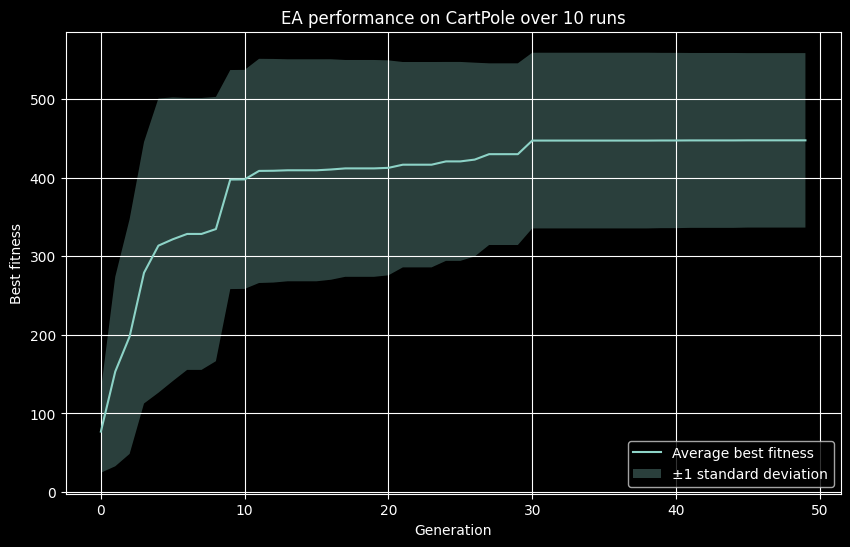

In [93]:
# ------------------------------------------------------------
# Plot average best fitness with standard deviation
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_fitness, label="Average best fitness")
plt.fill_between(
    generations,
    mean_fitness - std_fitness,
    mean_fitness + std_fitness,
    alpha=0.3,
    label="±1 standard deviation"
)

plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("EA performance on CartPole over 10 runs")
plt.legend()
plt.grid(True)
plt.show()

---
**Question 4 (0-0.25-0.5 pt):** Please comment on the average behavior of your algorithm. How did the average results and standard deviations look? Did your algorithm converge all the time to the best fitness?

**Answer:** \
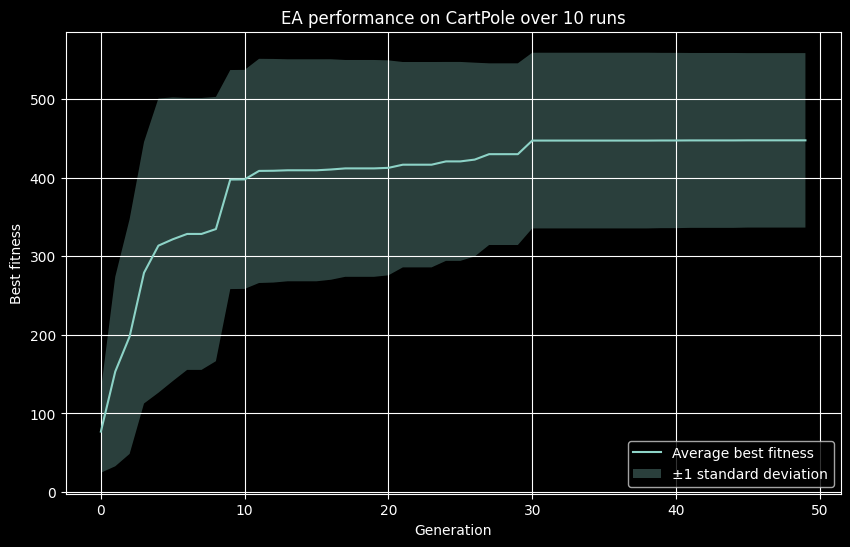
```
Final fitness values from all runs:
[500. 500. 500. 157. 318. 500. 500. 500. 500. 500.]

Average final fitness: 447.5
Standard deviation of final fitness: 111.00022522499673
Best final fitness achieved: 500.0
```

The average behavior of the algorithm shows that the fitness improves quickly during the early generations and then gradually stabilizes. The average best fitness starts around 77 in the first generation and increases rapidly within the first 10 generations, reaching roughly 400. After this point, improvements become slower and the algorithm gradually converges, ending with an average final fitness of about 447.5.

The standard deviation is relatively large, especially in the early generations. This indicates that the runs behave quite differently at the beginning due to the stochastic nature of the evolutionary algorithm, including random initialization, crossover, and mutation. As the generations progress, the standard deviation decreases somewhat, but it still remains around 111, which means there is still noticeable variability between runs.

From the 10 runs, the algorithm reached the maximum fitness of 500 in 8 runs, which means the pole was successfully balanced for the entire episode in most cases. However, a few runs converged to lower fitness values (157 and 318), which lowered the average result.

Overall, the algorithm did not converge to the optimal solution in every run, but it performed well in most cases. The results show that the evolutionary algorithm is good at finding the best solution, although sometimes it converges to bad solutions.
